$$
\providecommand{\bm}{\boldsymbol}
\providecommand{\R}{\mathbb{R}}
\providecommand{\E}{\mathbb{E}}
\providecommand{\xv}{\mathbf{x}}
\providecommand{\yv}{\mathbf{y}}
\providecommand{\thetav}{\bm{\theta}}
\providecommand{\thetab}{\bm{\theta}}
$$

INSERT_setup_intro

INSERT_seeds_note

INSERT_problem_a

**Solution.**

INSERT_solution_a_text

INSERT_problem_b

**Solution.**

INSERT_solution_b_text

INSERT_problem_c

Warning message:
"package 'gridExtra' was built under R version 4.4.3"


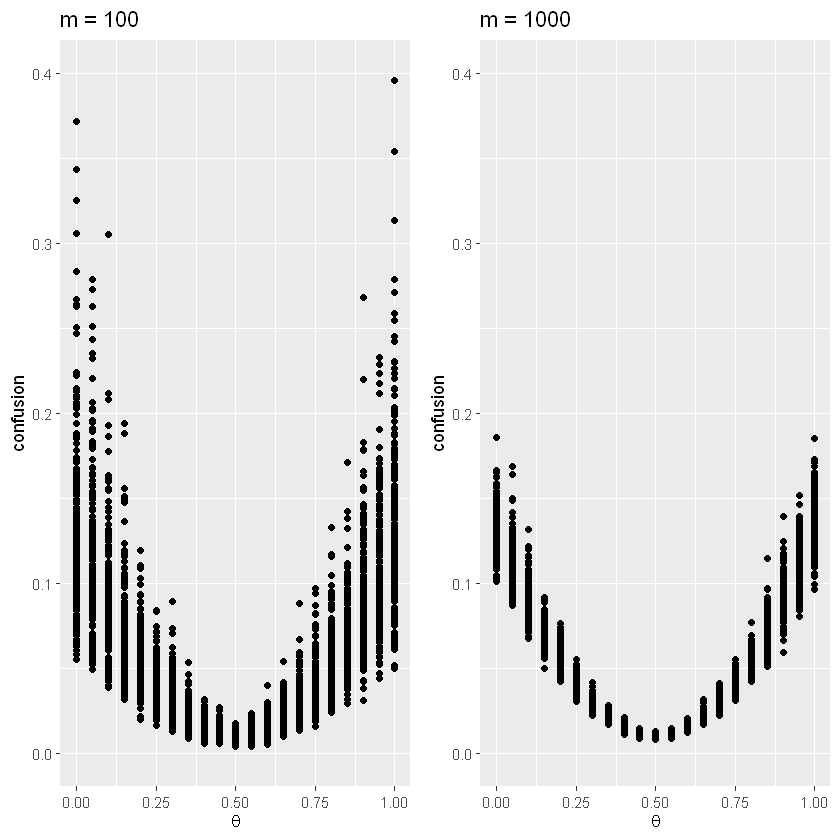

In [1]:
#| label: solution_c_code
library(ggplot2)
library(gridExtra)

set.seed(123)
sigma_x <- 0.5   # Sigma_x = 1/4, so sd = 1/2
sigma_y <- 0.1
theta_star <- 0.5

# data of size n (drawn once; each confusion below re-samples a fresh batch)
n <- 10000
x <- sort(rnorm(n, sd = sigma_x))
y <- theta_star * x + rnorm(n, sd = sigma_y)

# confusion: mean squared deviation of the per-sample gradients from the
# population gradient 2 * sigma_x^2 * (theta - theta_star)
compute_conf <- function(theta, m) {
  x <- rnorm(m, sd = sigma_x)
  y <- theta_star * x + rnorm(m, sd = sigma_y)
  mean((2 * (x * x * theta - y * x) - 2 * sigma_x^2 * (theta - theta_star))^2)
}

thetas <- seq(0, 1, length.out = 21)
reps <- 200

run_grid <- function(m) {
  confs <- c()
  for (i in 1:reps)
    for (theta in thetas) confs <- c(confs, compute_conf(theta, m))
  data.frame(theta = rep(thetas, reps), conf = confs)
}

df_100  <- run_grid(100)
df_1000 <- run_grid(1000)

p1 <- ggplot(df_100,  aes(theta, conf)) + geom_point() +
  ylim(0, 0.4) + xlab(expression(theta)) +
  ylab("confusion") + ggtitle("m = 100")
p2 <- ggplot(df_1000, aes(theta, conf)) + geom_point() +
  ylim(0, 0.4) + xlab(expression(theta)) +
  ylab("confusion") + ggtitle("m = 1000")
grid.arrange(p1, p2, ncol = 2)

INSERT_solution_c_text

INSERT_problem_d

**Solution.**

INSERT_solution_d_text

INSERT_problem_e

After 20 iters:  SGD mean = +0.4647, sd = 0.0626;  GD theta = +0.4806  (theta* = 0.5000)


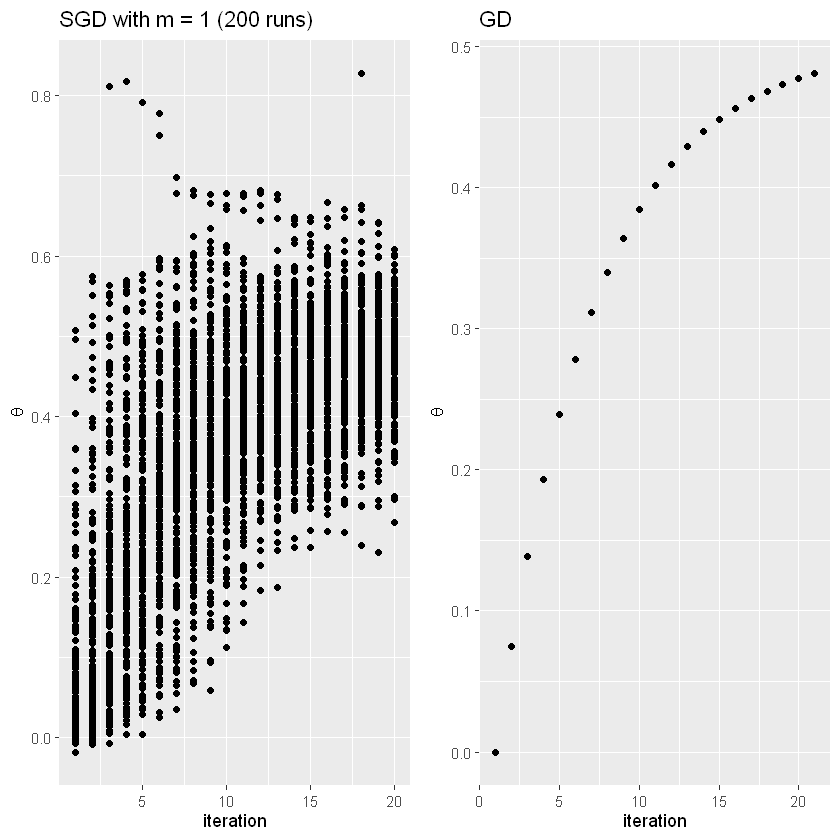

In [2]:
#| label: solution_e_code
set.seed(123)
alpha <- 0.3
n_iters <- 20
n_runs <- 200
m <- 1

# SGD with batch size 1
sgd_traces <- matrix(NA, n_runs, n_iters)
for (j in 1:n_runs) {
  theta <- 0
  for (i in 1:n_iters) {
    x <- rnorm(m, sd = sigma_x)
    y <- theta_star * x + rnorm(m, sd = sigma_y)
    theta <- theta - alpha * mean(2 * (x * x * theta - y * x))
    sgd_traces[j, i] <- theta
  }
}

# Population GD using the analytical gradient
# 2 * sigma_x^2 * (theta - theta_star)
theta <- 0
gd_trace <- theta
for (i in 1:n_iters) {
  theta <- theta - alpha * 2 * sigma_x^2 * (theta - theta_star)
  gd_trace <- c(gd_trace, theta)
}

df_sgd <- data.frame(it = rep(1:n_iters, each = n_runs),
                     theta = as.numeric(sgd_traces))
df_gd  <- data.frame(it = seq_along(gd_trace), theta = gd_trace)

p_sgd <- ggplot(df_sgd, aes(it, theta)) + geom_point() +
  ylab(expression(theta)) + xlab("iteration") +
  ggtitle("SGD with m = 1 (200 runs)")
p_gd <- ggplot(df_gd, aes(it, theta)) + geom_point() +
  ylab(expression(theta)) + xlab("iteration") + ggtitle("GD")
grid.arrange(p_sgd, p_gd, ncol = 2)

cat(sprintf(paste0(
  "After 20 iters:  SGD mean = %+.4f, sd = %.4f;  ",
  "GD theta = %+.4f  (theta* = %.4f)\n"),
            mean(sgd_traces[, n_iters]), sd(sgd_traces[, n_iters]),
            gd_trace[length(gd_trace)], theta_star))